In [1]:
%pip install yfinance pandas numpy matplotlib openpyxl

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings("ignore")

import math
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

from pathlib import Path
from dataclasses import dataclass

plt.rcParams["figure.figsize"] = (14, 6)
plt.rcParams["axes.grid"] = True

OUTPUT_DIR = Path("spy_momentum_project_output")
OUTPUT_DIR.mkdir(exist_ok=True)

TICKER = "SPY"
START_DATE = "2000-01-01"
END_DATE = None  # None means up to latest available
POST_COVID_START = "2020-03-01"
TRANSACTION_COST_BPS = 5  # 5 bps per position change

In [3]:
def download_price_data(ticker="SPY", start="2000-01-01", end=None):
    df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)

    if df.empty:
        raise ValueError(f"No data downloaded for {ticker}")

    # Flatten multi-index columns if they appear
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    required_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    df = df[required_cols].copy()
    df.index = pd.to_datetime(df.index)
    df = df.sort_index()

    # Use adjusted close for return calculations
    df["Return"] = df["Adj Close"].pct_change()
    df["LogReturn"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))
    df["NextReturn"] = df["Adj Close"].shift(-1) / df["Adj Close"] - 1
    df["NextDirection"] = np.sign(df["NextReturn"])

    return df

df = download_price_data(TICKER, START_DATE, END_DATE)
df.tail()

Price,Open,High,Low,Close,Adj Close,Volume,Return,LogReturn,NextReturn,NextDirection
Date,,,,,,,,,,
2026-03-10,677.719971,683.359985,674.760010,677.179993,677.179993,81505300,-0.001607,-0.001608,-0.001255,-1.0
2026-03-11,677.580017,680.080017,673.340027,676.330017,676.330017,68441700,-0.001255,-0.001256,-0.015185,-1.0
2026-03-12,671.159973,671.650024,665.869995,666.059998,666.059998,108882200,-0.015185,-0.015301,-0.005660,-1.0
2026-03-13,669.270020,672.340027,661.359985,662.289978,662.289978,97200200,-0.005660,-0.005676,0.010177,1.0
2026-03-16,668.380005,672.070007,667.119995,669.030029,669.030029,81253874,0.010177,0.010125,NaN,NaN


In [4]:
def ema(series, span):
    return series.ewm(span=span, adjust=False).mean()

def sma(series, window):
    return series.rolling(window).mean()

def rolling_zscore(series, window):
    mean_ = series.rolling(window).mean()
    std_ = series.rolling(window).std()
    return (series - mean_) / std_

def compute_rsi(close, window=14):
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.ewm(alpha=1/window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/window, adjust=False).mean()

    rs = avg_gain / avg_loss.replace(0, np.nan)
    rsi = 100 - (100 / (1 + rs))
    return rsi

def compute_stochastic(high, low, close, k_window=14, d_window=3):
    lowest_low = low.rolling(k_window).min()
    highest_high = high.rolling(k_window).max()
    k = 100 * (close - lowest_low) / (highest_high - lowest_low)
    d = k.rolling(d_window).mean()
    return k, d

def compute_roc(close, window=12):
    return 100 * (close / close.shift(window) - 1)

def compute_bollinger(close, window=20, num_std=2):
    mid = close.rolling(window).mean()
    std = close.rolling(window).std()
    upper = mid + num_std * std
    lower = mid - num_std * std
    return mid, upper, lower

def compute_williams_r(high, low, close, window=14):
    highest_high = high.rolling(window).max()
    lowest_low = low.rolling(window).min()
    wr = -100 * (highest_high - close) / (highest_high - lowest_low)
    return wr

def compute_cci(high, low, close, window=20):
    tp = (high + low + close) / 3
    sma_tp = tp.rolling(window).mean()
    mad = tp.rolling(window).apply(lambda x: np.mean(np.abs(x - np.mean(x))), raw=True)
    cci = (tp - sma_tp) / (0.015 * mad)
    return cci

def compute_true_range(high, low, close):
    prev_close = close.shift(1)
    tr = pd.concat([
        high - low,
        (high - prev_close).abs(),
        (low - prev_close).abs()
    ], axis=1).max(axis=1)
    return tr

def compute_atr(high, low, close, window=14):
    tr = compute_true_range(high, low, close)
    atr = tr.ewm(alpha=1/window, adjust=False).mean()
    return atr

def compute_adx(high, low, close, window=14):
    up_move = high.diff()
    down_move = -low.diff()

    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    plus_dm = pd.Series(plus_dm, index=high.index)
    minus_dm = pd.Series(minus_dm, index=high.index)

    tr = compute_true_range(high, low, close)
    atr = tr.ewm(alpha=1/window, adjust=False).mean()

    plus_di = 100 * plus_dm.ewm(alpha=1/window, adjust=False).mean() / atr
    minus_di = 100 * minus_dm.ewm(alpha=1/window, adjust=False).mean() / atr

    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di)
    adx = dx.ewm(alpha=1/window, adjust=False).mean()

    return adx, plus_di, minus_di

def max_drawdown(return_series):
    equity = (1 + return_series.fillna(0)).cumprod()
    running_max = equity.cummax()
    drawdown = equity / running_max - 1
    return drawdown.min()

def annualized_sharpe(return_series, periods_per_year=252):
    r = return_series.dropna()
    if len(r) < 2 or r.std() == 0:
        return np.nan
    return np.sqrt(periods_per_year) * r.mean() / r.std()

def annualized_return(return_series, periods_per_year=252):
    r = return_series.dropna()
    if len(r) == 0:
        return np.nan
    total = (1 + r).prod()
    years = len(r) / periods_per_year
    if years <= 0:
        return np.nan
    return total ** (1 / years) - 1

def hit_rate_from_signal(signal, next_return):
    aligned = pd.concat([signal, next_return], axis=1).dropna()
    aligned.columns = ["signal", "next_return"]
    aligned = aligned[aligned["signal"] != 0]
    if len(aligned) == 0:
        return np.nan
    return (np.sign(aligned["signal"]) == np.sign(aligned["next_return"])).mean()

def signal_coverage(signal):
    s = signal.dropna()
    if len(s) == 0:
        return np.nan
    return (s != 0).mean()

In [5]:
def candle_body(open_, close):
    return (close - open_).abs()

def candle_range(high, low):
    return high - low

def upper_shadow(open_, high, close):
    return high - np.maximum(open_, close)

def lower_shadow(open_, low, close):
    return np.minimum(open_, close) - low

def bullish_engulfing(open_, high, low, close):
    prev_open = open_.shift(1)
    prev_close = close.shift(1)

    prev_bear = prev_close < prev_open
    curr_bull = close > open_

    engulf = (open_ <= prev_close) & (close >= prev_open)
    return prev_bear & curr_bull & engulf

def bearish_engulfing(open_, high, low, close):
    prev_open = open_.shift(1)
    prev_close = close.shift(1)

    prev_bull = prev_close > prev_open
    curr_bear = close < open_

    engulf = (open_ >= prev_close) & (close <= prev_open)
    return prev_bull & curr_bear & engulf

def hammer(open_, high, low, close):
    body = candle_body(open_, close)
    rng = candle_range(high, low)
    lower = lower_shadow(open_, low, close)
    upper = upper_shadow(open_, high, close)

    cond = (
        (body / rng < 0.35) &
        (lower >= 2 * body) &
        (upper <= body)
    )
    return cond

def shooting_star(open_, high, low, close):
    body = candle_body(open_, close)
    rng = candle_range(high, low)
    lower = lower_shadow(open_, low, close)
    upper = upper_shadow(open_, high, close)

    cond = (
        (body / rng < 0.35) &
        (upper >= 2 * body) &
        (lower <= body)
    )
    return cond

def doji(open_, high, low, close):
    body = candle_body(open_, close)
    rng = candle_range(high, low)
    return (body / rng) <= 0.1

def morning_star(open_, high, low, close):
    o1, c1 = open_.shift(2), close.shift(2)
    o2, c2 = open_.shift(1), close.shift(1)
    o3, c3 = open_, close

    body2 = (c2 - o2).abs()
    body1 = (c1 - o1).abs()
    body3 = (c3 - o3).abs()

    cond = (
        (c1 < o1) &  # first candle bearish
        (body2 < body1 * 0.6) &
        (c3 > o3) &  # third candle bullish
        (c3 >= (o1 + c1) / 2)  # closes above midpoint of first candle
    )
    return cond

def evening_star(open_, high, low, close):
    o1, c1 = open_.shift(2), close.shift(2)
    o2, c2 = open_.shift(1), close.shift(1)
    o3, c3 = open_, close

    body2 = (c2 - o2).abs()
    body1 = (c1 - o1).abs()
    body3 = (c3 - o3).abs()

    cond = (
        (c1 > o1) &  # first candle bullish
        (body2 < body1 * 0.6) &
        (c3 < o3) &  # third candle bearish
        (c3 <= (o1 + c1) / 2)  # closes below midpoint of first candle
    )
    return cond

In [6]:
def build_indicators(df):
    out = df.copy()

    close = out["Adj Close"]
    open_ = out["Open"]
    high = out["High"]
    low = out["Low"]
    volume = out["Volume"]

    # Trend / momentum basics
    out["SMA_20"] = sma(close, 20)
    out["SMA_50"] = sma(close, 50)
    out["SMA_100"] = sma(close, 100)
    out["SMA_200"] = sma(close, 200)

    out["EMA_12"] = ema(close, 12)
    out["EMA_26"] = ema(close, 26)
    out["EMA_50"] = ema(close, 50)

    # MACD
    out["MACD"] = out["EMA_12"] - out["EMA_26"]
    out["MACD_SIGNAL"] = ema(out["MACD"], 9)
    out["MACD_HIST"] = out["MACD"] - out["MACD_SIGNAL"]

    # RSI
    out["RSI_14"] = compute_rsi(close, 14)

    # Stochastic
    out["STOCH_K"], out["STOCH_D"] = compute_stochastic(high, low, close, 14, 3)

    # ROC
    out["ROC_12"] = compute_roc(close, 12)

    # Bollinger
    out["BB_MID"], out["BB_UPPER"], out["BB_LOWER"] = compute_bollinger(close, 20, 2)
    out["BB_ZSCORE_20"] = rolling_zscore(close, 20)

    # Williams %R
    out["WILLR_14"] = compute_williams_r(high, low, close, 14)

    # CCI
    out["CCI_20"] = compute_cci(high, low, close, 20)

    # ATR
    out["ATR_14"] = compute_atr(high, low, close, 14)
    out["ATR_PCT"] = out["ATR_14"] / close

    # ADX and DIs
    out["ADX_14"], out["PLUS_DI_14"], out["MINUS_DI_14"] = compute_adx(high, low, close, 14)

    # Breakout features
    out["HH_20"] = high.rolling(20).max()
    out["LL_20"] = low.rolling(20).min()
    out["HH_50"] = high.rolling(50).max()
    out["LL_50"] = low.rolling(50).min()

    # Volume features
    out["VOL_SMA_20"] = sma(volume, 20)
    out["VOL_RATIO_20"] = volume / out["VOL_SMA_20"]

    # Candlestick patterns
    out["PAT_BULL_ENGULF"] = bullish_engulfing(open_, high, low, close).astype(int)
    out["PAT_BEAR_ENGULF"] = bearish_engulfing(open_, high, low, close).astype(int)
    out["PAT_HAMMER"] = hammer(open_, high, low, close).astype(int)
    out["PAT_SHOOTING_STAR"] = shooting_star(open_, high, low, close).astype(int)
    out["PAT_DOJI"] = doji(open_, high, low, close).astype(int)
    out["PAT_MORNING_STAR"] = morning_star(open_, high, low, close).astype(int)
    out["PAT_EVENING_STAR"] = evening_star(open_, high, low, close).astype(int)

    return out

df_ind = build_indicators(df)
df_ind.tail()

Price,Open,High,Low,Close,Adj Close,Volume,Return,LogReturn,NextReturn,NextDirection,...,LL_50,VOL_SMA_20,VOL_RATIO_20,PAT_BULL_ENGULF,PAT_BEAR_ENGULF,PAT_HAMMER,PAT_SHOOTING_STAR,PAT_DOJI,PAT_MORNING_STAR,PAT_EVENING_STAR
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-10,677.719971,683.359985,674.760010,677.179993,677.179993,81505300,-0.001607,-0.001608,-0.001255,-1.0,...,662.390015,85453985.0,0.953792,0,0,0,0,1,0,0
2026-03-11,677.580017,680.080017,673.340027,676.330017,676.330017,68441700,-0.001255,-0.001256,-0.015185,-1.0,...,662.390015,85616785.0,0.799396,0,0,0,0,0,0,0
2026-03-12,671.159973,671.650024,665.869995,666.059998,666.059998,108882200,-0.015185,-0.015301,-0.005660,-1.0,...,662.390015,87243200.0,1.248031,0,0,0,0,0,0,0
2026-03-13,669.270020,672.340027,661.359985,662.289978,662.289978,97200200,-0.005660,-0.005676,0.010177,1.0,...,661.359985,86161760.0,1.128113,0,0,0,0,0,0,0
2026-03-16,668.380005,672.070007,667.119995,669.030029,669.030029,81253874,0.010177,0.010125,NaN,NaN,...,661.359985,85411078.7,0.951327,0,0,0,0,0,0,0


In [7]:
def build_signal_matrix(df):
    sig = pd.DataFrame(index=df.index)

    # 1) SMA 50/200 cross
    sig["SMA_CROSS_50_200"] = np.where(df["SMA_50"] > df["SMA_200"], 1, -1)

    # 2) EMA 12/26 cross
    sig["EMA_CROSS_12_26"] = np.where(df["EMA_12"] > df["EMA_26"], 1, -1)

    # 3) MACD line vs signal
    sig["MACD_SIGNAL"] = np.where(df["MACD"] > df["MACD_SIGNAL"], 1, -1)

    # 4) MACD histogram sign
    sig["MACD_HIST_SIGN"] = np.where(df["MACD_HIST"] > 0, 1, -1)

    # 5) RSI regime
    sig["RSI_14"] = np.select(
        [
            df["RSI_14"] < 30,
            df["RSI_14"] > 70
        ],
        [1, -1],
        default=0
    )

    # 6) Stochastic K vs D
    sig["STOCH_CROSS"] = np.where(df["STOCH_K"] > df["STOCH_D"], 1, -1)

    # 7) ROC sign
    sig["ROC_12"] = np.where(df["ROC_12"] > 0, 1, -1)

    # 8) Bollinger reversal
    sig["BOLLINGER_REV"] = np.select(
        [
            df["Adj Close"] < df["BB_LOWER"],
            df["Adj Close"] > df["BB_UPPER"]
        ],
        [1, -1],
        default=0
    )

    # 9) Williams %R
    sig["WILLR_14"] = np.select(
        [
            df["WILLR_14"] < -80,
            df["WILLR_14"] > -20
        ],
        [1, -1],
        default=0
    )

    # 10) CCI
    sig["CCI_20"] = np.select(
        [
            df["CCI_20"] < -100,
            df["CCI_20"] > 100
        ],
        [1, -1],
        default=0
    )

    # 11) ADX trend with DI direction
    sig["ADX_DI"] = np.select(
        [
            (df["ADX_14"] >= 20) & (df["PLUS_DI_14"] > df["MINUS_DI_14"]),
            (df["ADX_14"] >= 20) & (df["PLUS_DI_14"] < df["MINUS_DI_14"])
        ],
        [1, -1],
        default=0
    )

    # 12) Price vs 200d SMA
    sig["PRICE_VS_SMA200"] = np.where(df["Adj Close"] > df["SMA_200"], 1, -1)

    # 13) 20-day breakout
    sig["BREAKOUT_20"] = np.select(
        [
            df["Adj Close"] >= df["HH_20"].shift(1),
            df["Adj Close"] <= df["LL_20"].shift(1)
        ],
        [1, -1],
        default=0
    )

    # 14) 50-day breakout
    sig["BREAKOUT_50"] = np.select(
        [
            df["Adj Close"] >= df["HH_50"].shift(1),
            df["Adj Close"] <= df["LL_50"].shift(1)
        ],
        [1, -1],
        default=0
    )

    # Candlestick signals
    sig["BULL_ENGULF"] = np.where(df["PAT_BULL_ENGULF"] == 1, 1, 0)
    sig["BEAR_ENGULF"] = np.where(df["PAT_BEAR_ENGULF"] == 1, -1, 0)
    sig["HAMMER"] = np.where(df["PAT_HAMMER"] == 1, 1, 0)
    sig["SHOOTING_STAR"] = np.where(df["PAT_SHOOTING_STAR"] == 1, -1, 0)
    sig["MORNING_STAR"] = np.where(df["PAT_MORNING_STAR"] == 1, 1, 0)
    sig["EVENING_STAR"] = np.where(df["PAT_EVENING_STAR"] == 1, -1, 0)

    # Doji is neutral by itself, but useful as a flag
    sig["DOJI_NEUTRAL"] = 0

    # Optional combined candlestick composite
    sig["CANDLE_COMPOSITE"] = (
        sig["BULL_ENGULF"]
        + sig["HAMMER"]
        + sig["MORNING_STAR"]
        + sig["BEAR_ENGULF"]
        + sig["SHOOTING_STAR"]
        + sig["EVENING_STAR"]
    )
    sig["CANDLE_COMPOSITE"] = np.sign(sig["CANDLE_COMPOSITE"])

    return sig.astype(float)

signal_df = build_signal_matrix(df_ind)
signal_df.tail()

,SMA_CROSS_50_200,EMA_CROSS_12_26,MACD_SIGNAL,MACD_HIST_SIGN,RSI_14,STOCH_CROSS,ROC_12,BOLLINGER_REV,WILLR_14,CCI_20,...,BREAKOUT_20,BREAKOUT_50,BULL_ENGULF,BEAR_ENGULF,HAMMER,SHOOTING_STAR,MORNING_STAR,EVENING_STAR,DOJI_NEUTRAL,CANDLE_COMPOSITE
Date,,,,,,,,,,,,,,,,,,,,,
2026-03-10,1.0,-1.0,-1.0,-1.0,0.0,1.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-11,1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-12,1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-13,1.0,-1.0,-1.0,-1.0,0.0,-1.0,-1.0,1.0,1.0,1.0,...,-1.0,-1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2026-03-16,1.0,-1.0,-1.0,-1.0,0.0,1.0,-1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
@dataclass
class BacktestResult:
    name: str
    hit_rate: float
    coverage: float
    total_return: float
    annual_return: float
    sharpe: float
    max_drawdown: float
    avg_daily_return: float
    n_trades: int

def backtest_signal(signal, returns, transaction_cost_bps=5):
    signal = signal.copy().fillna(0)

    # Trade next day using today's signal
    position = signal.shift(1).fillna(0)

    # Transaction cost when position changes
    turnover = position.diff().abs().fillna(position.abs())
    tc = turnover * (transaction_cost_bps / 10000)

    strategy_return = position * returns - tc
    strategy_return = strategy_return.fillna(0)

    return strategy_return, position

def evaluate_signal(name, signal, next_return, same_day_return, transaction_cost_bps=5):
    # Accuracy: compare today's signal to next day's return
    hr = hit_rate_from_signal(signal, next_return)
    cov = signal_coverage(signal)

    strat_ret, pos = backtest_signal(signal, same_day_return, transaction_cost_bps)

    total_ret = (1 + strat_ret).prod() - 1
    ann_ret = annualized_return(strat_ret)
    sharpe = annualized_sharpe(strat_ret)
    mdd = max_drawdown(strat_ret)
    avg_daily = strat_ret.mean()
    n_trades = int((pos.diff().abs().fillna(pos.abs()) > 0).sum())

    result = BacktestResult(
        name=name,
        hit_rate=hr,
        coverage=cov,
        total_return=total_ret,
        annual_return=ann_ret,
        sharpe=sharpe,
        max_drawdown=mdd,
        avg_daily_return=avg_daily,
        n_trades=n_trades
    )

    return result, strat_ret, pos

In [9]:
def evaluate_all_indicators(df, signal_df, post_covid_start="2020-03-01", transaction_cost_bps=5):
    results_all = []
    results_post = []

    strategy_returns = pd.DataFrame(index=df.index)
    positions = pd.DataFrame(index=df.index)

    for col in signal_df.columns:
        signal = signal_df[col]

        # Full sample
        res_all, strat_ret, pos = evaluate_signal(
            col,
            signal=signal,
            next_return=df["NextReturn"],
            same_day_return=df["Return"],
            transaction_cost_bps=transaction_cost_bps
        )
        results_all.append(res_all.__dict__)

        strategy_returns[col] = strat_ret
        positions[col] = pos

        # Post-COVID
        mask = df.index >= pd.to_datetime(post_covid_start)
        res_post, _, _ = evaluate_signal(
            col,
            signal=signal.loc[mask],
            next_return=df.loc[mask, "NextReturn"],
            same_day_return=df.loc[mask, "Return"],
            transaction_cost_bps=transaction_cost_bps
        )
        results_post.append(res_post.__dict__)

    full_df = pd.DataFrame(results_all).sort_values(
        ["hit_rate", "sharpe", "annual_return"], ascending=False
    ).reset_index(drop=True)

    post_df = pd.DataFrame(results_post).sort_values(
        ["hit_rate", "sharpe", "annual_return"], ascending=False
    ).reset_index(drop=True)

    return full_df, post_df, strategy_returns, positions

summary_full, summary_post, strategy_returns, positions = evaluate_all_indicators(
    df_ind, signal_df, POST_COVID_START, TRANSACTION_COST_BPS
)

summary_full.head(15)

,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,MORNING_STAR,0.615385,0.001973,0.005995,0.000229,0.066688,-0.012575,9.316339e-07,24
1,WILLR_14,0.543825,0.922902,4.350998,0.066251,0.435410,-0.551894,3.246646e-04,193
2,BEAR_ENGULF,0.538462,0.001973,0.009616,0.000366,0.046338,-0.026684,1.603032e-06,26
3,SMA_CROSS_50_200,0.536278,1.000000,3.213270,0.056547,0.381459,-0.402415,2.928882e-04,28
4,PRICE_VS_SMA200,0.533394,1.000000,1.142858,0.029577,0.247778,-0.441306,1.903045e-04,164
5,BOLLINGER_REV,0.527454,0.091213,0.768252,0.022039,0.322437,-0.155754,9.790337e-05,713
6,EMA_CROSS_12_26,0.514268,1.000000,-0.431268,-0.021352,-0.014374,-0.653130,-1.104079e-05,215
7,ROC_12,0.511384,1.000000,-0.408864,-0.019905,-0.006848,-0.762844,-5.259750e-06,801
8,STOCH_CROSS,0.506679,1.000000,-0.911879,-0.088716,-0.382337,-0.947971,-2.939809e-04,2097
9,HAMMER,0.500000,0.000304,-0.000427,-0.000016,-0.014913,-0.004479,-6.253807e-08,4


In [10]:
print("Top 10 indicators by full-history directional accuracy:")
display(summary_full.head(10))

print("\nTop 10 indicators by post-COVID directional accuracy:")
display(summary_post.head(10))

Top 10 indicators by full-history directional accuracy:


,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,MORNING_STAR,0.615385,0.001973,0.005995,0.000229,0.066688,-0.012575,9.316339e-07,24
1,WILLR_14,0.543825,0.922902,4.350998,0.066251,0.435410,-0.551894,3.246646e-04,193
2,BEAR_ENGULF,0.538462,0.001973,0.009616,0.000366,0.046338,-0.026684,1.603032e-06,26
3,SMA_CROSS_50_200,0.536278,1.000000,3.213270,0.056547,0.381459,-0.402415,2.928882e-04,28
4,PRICE_VS_SMA200,0.533394,1.000000,1.142858,0.029577,0.247778,-0.441306,1.903045e-04,164
5,BOLLINGER_REV,0.527454,0.091213,0.768252,0.022039,0.322437,-0.155754,9.790337e-05,713
6,EMA_CROSS_12_26,0.514268,1.000000,-0.431268,-0.021352,-0.014374,-0.653130,-1.104079e-05,215
7,ROC_12,0.511384,1.000000,-0.408864,-0.019905,-0.006848,-0.762844,-5.259750e-06,801
8,STOCH_CROSS,0.506679,1.000000,-0.911879,-0.088716,-0.382337,-0.947971,-2.939809e-04,2097
9,HAMMER,0.500000,0.000304,-0.000427,-0.000016,-0.014913,-0.004479,-6.253807e-08,4



Top 10 indicators by post-COVID directional accuracy:


,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,MORNING_STAR,0.615385,0.008564,0.005995,0.000993,0.138906,-0.012575,0.000004,24
1,PRICE_VS_SMA200,0.552406,1.000000,0.478293,0.067042,0.419388,-0.284263,0.000341,33
2,BOLLINGER_REV,0.546763,0.091568,0.388806,0.056038,0.728546,-0.121196,0.000228,179
3,WILLR_14,0.546432,0.673913,0.718944,0.094096,0.581632,-0.283190,0.000424,193
4,SMA_CROSS_50_200,0.538563,1.000000,0.155787,0.024326,0.220008,-0.353746,0.000179,7
5,BEAR_ENGULF,0.538462,0.008564,0.009616,0.001590,0.096518,-0.026684,0.000007,26
6,ROC_12,0.534608,1.000000,0.552994,0.075810,0.459195,-0.258214,0.000373,173
7,EMA_CROSS_12_26,0.529334,1.000000,0.476587,0.066838,0.418342,-0.237898,0.000340,39
8,STOCH_CROSS,0.508899,1.000000,-0.469714,-0.099950,-0.410647,-0.477855,-0.000334,566
9,ADX_DI,0.503928,0.587615,-0.408018,-0.083354,-0.392645,-0.553970,-0.000281,102


In [11]:
TOP_N = 10

top_full_names = summary_full.head(TOP_N)["name"].tolist()
top_post_names = summary_post.head(TOP_N)["name"].tolist()

signal_df["ENSEMBLE_TOP10_FULL"] = np.sign(signal_df[top_full_names].sum(axis=1))
signal_df["ENSEMBLE_TOP10_POSTCOVID"] = np.sign(signal_df[top_post_names].sum(axis=1))

# Evaluate the two ensemble signals
ensemble_full_res, ensemble_full_ret, ensemble_full_pos = evaluate_signal(
    "ENSEMBLE_TOP10_FULL",
    signal_df["ENSEMBLE_TOP10_FULL"],
    df_ind["NextReturn"],
    df_ind["Return"],
    TRANSACTION_COST_BPS
)

ensemble_post_res, ensemble_post_ret, ensemble_post_pos = evaluate_signal(
    "ENSEMBLE_TOP10_POSTCOVID",
    signal_df["ENSEMBLE_TOP10_POSTCOVID"],
    df_ind["NextReturn"],
    df_ind["Return"],
    TRANSACTION_COST_BPS
)

pd.DataFrame([ensemble_full_res.__dict__, ensemble_post_res.__dict__])

,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,ENSEMBLE_TOP10_FULL,0.540475,0.881317,1.662000,0.038155,0.300955,-0.530046,0.000210,902
1,ENSEMBLE_TOP10_POSTCOVID,0.533258,0.937775,0.412662,0.013301,0.164259,-0.480187,0.000121,760


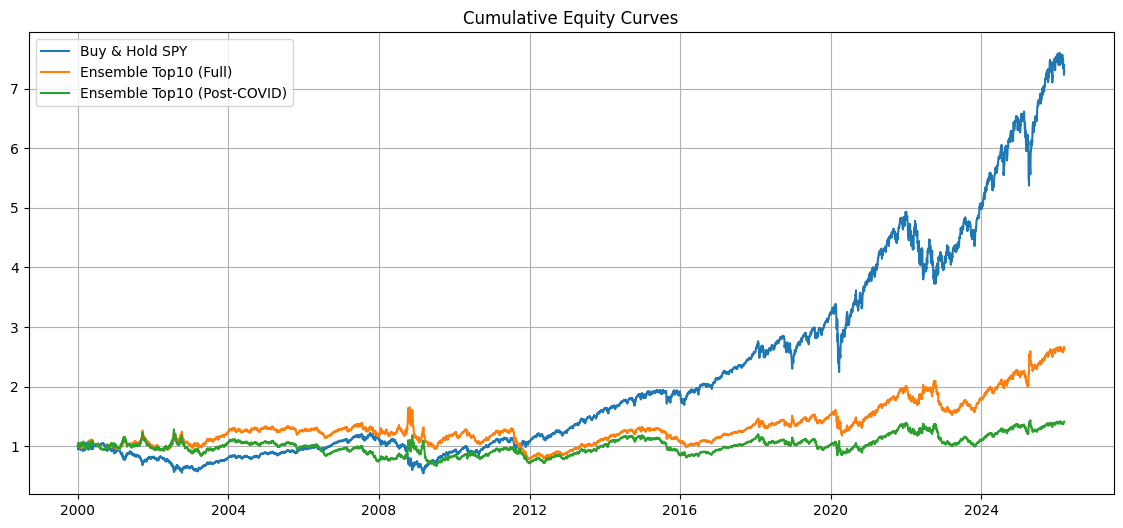

In [12]:
buy_hold = df_ind["Return"].fillna(0)
equity_buy_hold = (1 + buy_hold).cumprod()
equity_ens_full = (1 + ensemble_full_ret.fillna(0)).cumprod()
equity_ens_post = (1 + ensemble_post_ret.fillna(0)).cumprod()

plt.figure(figsize=(14, 6))
plt.plot(equity_buy_hold.index, equity_buy_hold, label="Buy & Hold SPY")
plt.plot(equity_ens_full.index, equity_ens_full, label="Ensemble Top10 (Full)")
plt.plot(equity_ens_post.index, equity_ens_post, label="Ensemble Top10 (Post-COVID)")
plt.title("Cumulative Equity Curves")
plt.legend()
plt.show()

The first graph compares buy-and-hold SPY with two ensemble strategies built from the top-ranked indicators. The main finding is that buy-and-hold still dominates in raw cumulative return over the full sample, which is not surprising given the strong long-run upward drift of U.S. equities, especially after major recoveries such as the post-2009 bull market and the rebound after the 2020 COVID shock. However, the ensemble strategies still provide useful information. The full-sample Top 10 ensemble grows more steadily than many individual indicators and appears to capture part of the market’s long-run trend, but it still underperforms passive holding because it likely enters trends late and exits after damage has already occurred, which is a common limitation of rule-based momentum systems. The post-COVID ensemble performs even more conservatively, suggesting that indicators selected only on recent data may be more regime-specific and less powerful over the broader sample. This implies that while ensemble methods can smooth out the weaknesses of individual signals and reduce dependence on any single rule, they do not automatically outperform a strong benchmark like SPY buy-and-hold. The broader inference is that the momentum indicators in this project may have more value as timing, regime-detection, or risk-management tools rather than as pure return-maximizing replacements for passive exposure. In future extensions, these indicator systems may become more competitive if they are used selectively—such as only in high-volatility regimes, or as overlays that scale exposure up or down—rather than forcing a constant binary trading rule across all market environments.

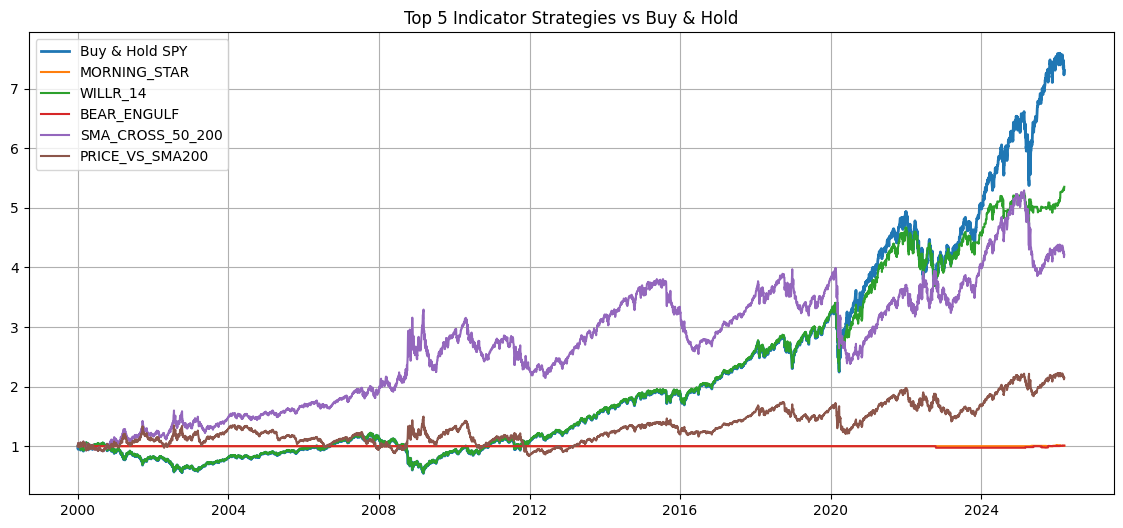

In [13]:
top5 = summary_full.head(5)["name"].tolist()

plt.figure(figsize=(14, 6))
plt.plot((1 + df_ind["Return"].fillna(0)).cumprod(), label="Buy & Hold SPY", linewidth=2)

for name in top5:
    eq = (1 + strategy_returns[name].fillna(0)).cumprod()
    plt.plot(eq, label=name)

plt.title("Top 5 Indicator Strategies vs Buy & Hold")
plt.legend()
plt.show()

The second graph is especially informative because it reveals large differences in the quality, stability, and economic plausibility of the individual indicators. Among the top five shown, SMA_CROSS_50_200 stands out as one of the strongest and most credible signals, delivering substantial long-run growth and a relatively coherent trend-following profile. Its behavior suggests that medium-to-long-horizon moving-average trend rules are able to participate in extended bull markets while also reducing some exposure during weaker regimes. At the same time, the graph shows that this strategy suffers noticeably during abrupt crash-and-rebound episodes, especially around COVID, which reflects the classic weakness of slow moving-average systems: they respond too late to fast reversals and can be whipsawed by violent regime shifts. WILLR_14 also performs surprisingly well, implying that overbought/oversold information may contain useful short-term timing content, especially when the market repeatedly mean-reverts within a broader upward trend; however, because Williams %R is a faster oscillator, its apparent success may be more sensitive to sample period and parameter choice, so its future potential is promising but probably less structurally robust than the SMA trend rule. PRICE_VS_SMA200 appears weaker than the full crossover strategy but still directionally sensible, indicating that a simple filter based on whether price is above or below its long-run trend can add value, though it may be too coarse to capture turning points efficiently. By contrast, MORNING_STAR and BEAR_ENGULF look far less convincing as standalone trading strategies: their equity curves are relatively flat, unstable, or economically weak, suggesting that candlestick patterns by themselves may fire too infrequently, be too noisy, or lack enough persistent predictive power to drive a full systematic strategy on SPY. The main inference from this graph is that trend-based indicators seem much more promising than isolated candlestick rules for this project. In terms of future potential, the moving-average family likely deserves the most follow-up testing—such as comparing 20/50, 50/100, and 100/200 crossovers, or combining trend signals with volatility filters—while the candlestick indicators may still be useful as secondary confirmation signals rather than primary drivers of portfolio allocation.

In [14]:
coverage_table = pd.DataFrame({
    "Indicator": signal_df.columns,
    "CoverageRate": [signal_coverage(signal_df[c]) for c in signal_df.columns]
}).sort_values("CoverageRate", ascending=False)

coverage_table.head(20)

,Indicator,CoverageRate
0,SMA_CROSS_50_200,1.000000
1,EMA_CROSS_12_26,1.000000
2,MACD_SIGNAL,1.000000
3,MACD_HIST_SIGN,1.000000
5,STOCH_CROSS,1.000000
6,ROC_12,1.000000
11,PRICE_VS_SMA200,1.000000
23,ENSEMBLE_TOP10_POSTCOVID,0.937775
8,WILLR_14,0.922902
22,ENSEMBLE_TOP10_FULL,0.881317


In [15]:
def minmax(series):
    s = series.copy()
    if s.max() == s.min():
        return pd.Series(0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

rank_table = summary_full.copy()

rank_table["score_hit_rate"] = minmax(rank_table["hit_rate"])
rank_table["score_sharpe"] = minmax(rank_table["sharpe"].replace([np.inf, -np.inf], np.nan).fillna(0))
rank_table["score_ann_return"] = minmax(rank_table["annual_return"].replace([np.inf, -np.inf], np.nan).fillna(0))
rank_table["score_coverage"] = minmax(rank_table["coverage"].fillna(0))

rank_table["blended_score"] = (
    0.40 * rank_table["score_hit_rate"] +
    0.30 * rank_table["score_sharpe"] +
    0.20 * rank_table["score_ann_return"] +
    0.10 * rank_table["score_coverage"]
)

rank_table = rank_table.sort_values("blended_score", ascending=False).reset_index(drop=True)
rank_table.head(10)

,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades,score_hit_rate,score_sharpe,score_ann_return,score_coverage,blended_score
0,WILLR_14,0.543825,0.922902,4.350998,0.066251,0.435410,-0.551894,3.246646e-04,193,0.883716,1.000000,1.000000,0.922902,0.945776
1,SMA_CROSS_50_200,0.536278,1.000000,3.213270,0.056547,0.381459,-0.402415,2.928882e-04,28,0.871452,0.937790,0.937953,1.000000,0.917509
2,PRICE_VS_SMA200,0.533394,1.000000,1.142858,0.029577,0.247778,-0.441306,1.903045e-04,164,0.866765,0.783646,0.765504,1.000000,0.834901
3,RSI_14,0.497615,0.095462,0.926232,0.025389,0.391422,-0.116193,1.089856e-04,398,0.808625,0.949278,0.738725,0.095462,0.765525
4,BOLLINGER_REV,0.527454,0.091213,0.768252,0.022039,0.322437,-0.155754,9.790337e-05,713,0.857113,0.869734,0.717302,0.091213,0.756347
5,CCI_20,0.496534,0.459857,0.439815,0.014039,0.169950,-0.465791,9.229342e-05,1433,0.806867,0.693904,0.666147,0.459857,0.710133
6,MORNING_STAR,0.615385,0.001973,0.005995,0.000229,0.066688,-0.012575,9.316339e-07,24,1.000000,0.574835,0.577842,0.001973,0.688216
7,ROC_12,0.511384,1.000000,-0.408864,-0.019905,-0.006848,-0.762844,-5.259750e-06,801,0.831000,0.490043,0.449103,1.000000,0.669233
8,EMA_CROSS_12_26,0.514268,1.000000,-0.431268,-0.021352,-0.014374,-0.653130,-1.104079e-05,215,0.835686,0.481365,0.439849,1.000000,0.666654
9,BEAR_ENGULF,0.538462,0.001973,0.009616,0.000366,0.046338,-0.026684,1.603032e-06,26,0.875000,0.551371,0.578722,0.001973,0.631353


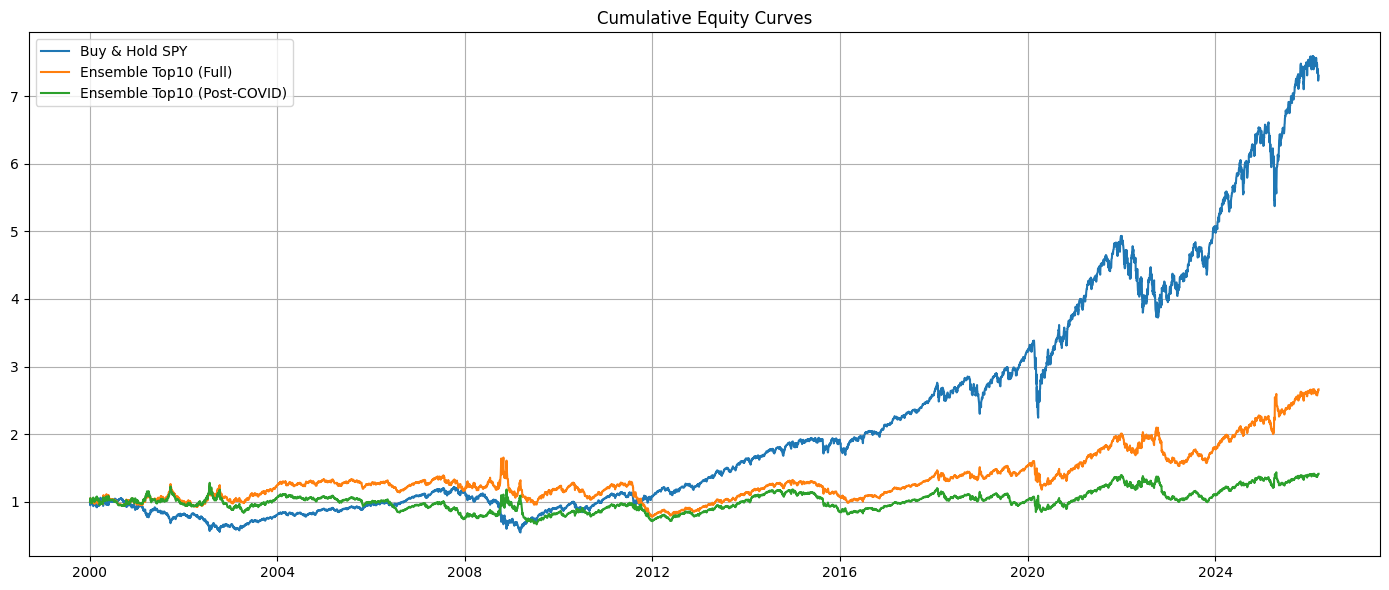

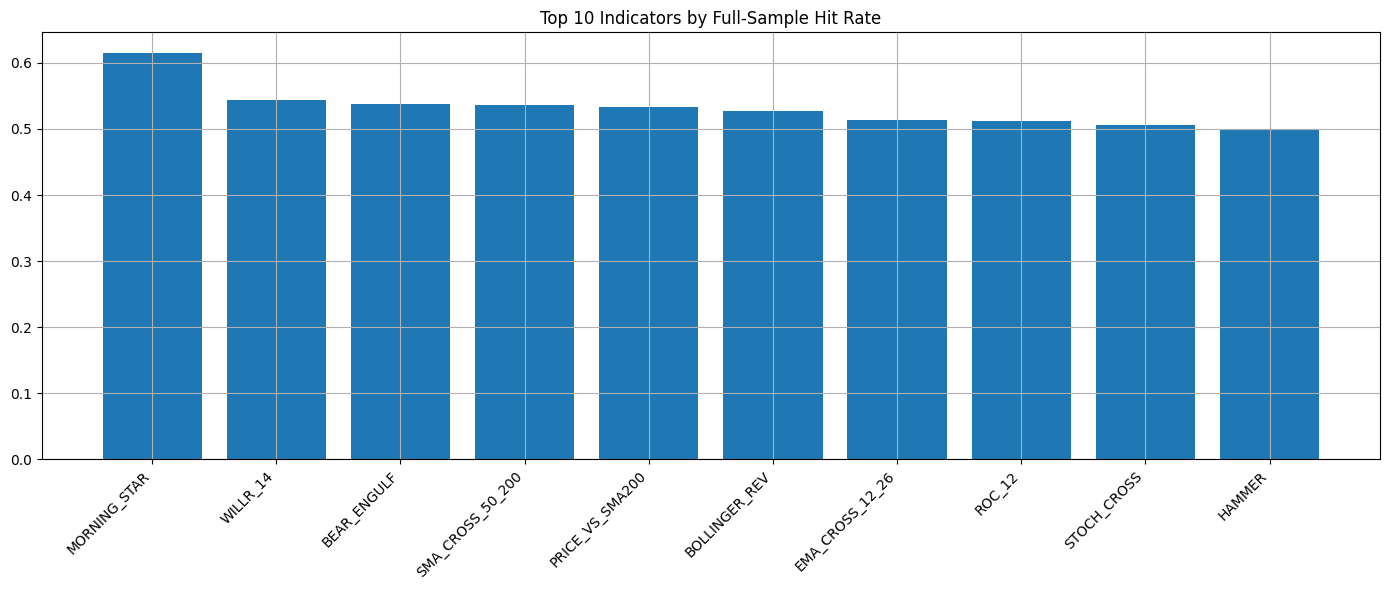

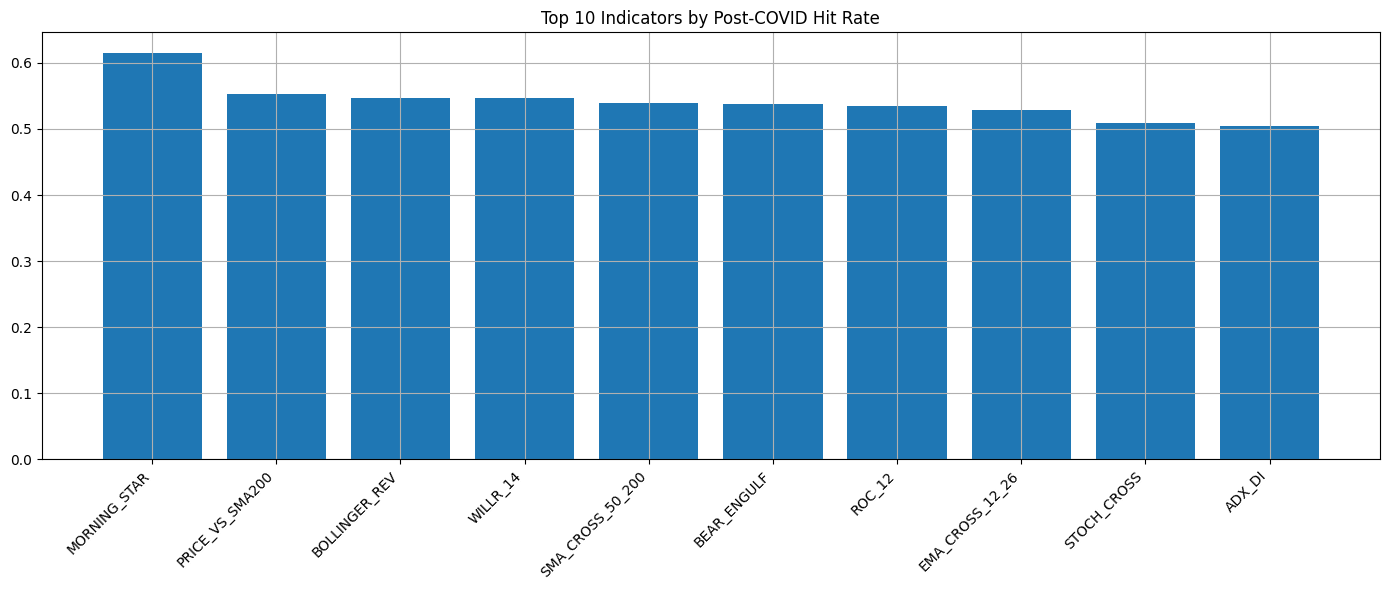

In [16]:
# Equity curve chart
plt.figure(figsize=(14, 6))
plt.plot(equity_buy_hold.index, equity_buy_hold, label="Buy & Hold SPY")
plt.plot(equity_ens_full.index, equity_ens_full, label="Ensemble Top10 (Full)")
plt.plot(equity_ens_post.index, equity_ens_post, label="Ensemble Top10 (Post-COVID)")
plt.title("Cumulative Equity Curves")
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "equity_curves.png", dpi=200)
plt.show()

# Top 10 hit rate chart
top10_plot = summary_full.head(10).copy()
plt.figure(figsize=(14, 6))
plt.bar(top10_plot["name"], top10_plot["hit_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Indicators by Full-Sample Hit Rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top10_hit_rate_full.png", dpi=200)
plt.show()

# Top 10 post-COVID hit rate chart
top10_post_plot = summary_post.head(10).copy()
plt.figure(figsize=(14, 6))
plt.bar(top10_post_plot["name"], top10_post_plot["hit_rate"])
plt.xticks(rotation=45, ha="right")
plt.title("Top 10 Indicators by Post-COVID Hit Rate")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "top10_hit_rate_postcovid.png", dpi=200)
plt.show()

In [17]:
print("=" * 80)
print("PROJECT SUMMARY")
print("=" * 80)

print(f"Ticker: {TICKER}")
print(f"Data start: {df_ind.index.min().date()}")
print(f"Data end:   {df_ind.index.max().date()}")
print(f"Post-COVID period starts: {POST_COVID_START}")
print()

print("Top 10 indicators by full-sample hit rate:")
display(summary_full.head(10))

print("Top 10 indicators by post-COVID hit rate:")
display(summary_post.head(10))

print("Ensemble results:")
display(pd.DataFrame([ensemble_full_res.__dict__, ensemble_post_res.__dict__]))

print(f"All outputs saved in folder: {OUTPUT_DIR.resolve()}")

PROJECT SUMMARY
Ticker: SPY
Data start: 2000-01-03
Data end:   2026-03-16
Post-COVID period starts: 2020-03-01

Top 10 indicators by full-sample hit rate:


,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,MORNING_STAR,0.615385,0.001973,0.005995,0.000229,0.066688,-0.012575,9.316339e-07,24
1,WILLR_14,0.543825,0.922902,4.350998,0.066251,0.435410,-0.551894,3.246646e-04,193
2,BEAR_ENGULF,0.538462,0.001973,0.009616,0.000366,0.046338,-0.026684,1.603032e-06,26
3,SMA_CROSS_50_200,0.536278,1.000000,3.213270,0.056547,0.381459,-0.402415,2.928882e-04,28
4,PRICE_VS_SMA200,0.533394,1.000000,1.142858,0.029577,0.247778,-0.441306,1.903045e-04,164
5,BOLLINGER_REV,0.527454,0.091213,0.768252,0.022039,0.322437,-0.155754,9.790337e-05,713
6,EMA_CROSS_12_26,0.514268,1.000000,-0.431268,-0.021352,-0.014374,-0.653130,-1.104079e-05,215
7,ROC_12,0.511384,1.000000,-0.408864,-0.019905,-0.006848,-0.762844,-5.259750e-06,801
8,STOCH_CROSS,0.506679,1.000000,-0.911879,-0.088716,-0.382337,-0.947971,-2.939809e-04,2097
9,HAMMER,0.500000,0.000304,-0.000427,-0.000016,-0.014913,-0.004479,-6.253807e-08,4


Top 10 indicators by post-COVID hit rate:


,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,MORNING_STAR,0.615385,0.008564,0.005995,0.000993,0.138906,-0.012575,0.000004,24
1,PRICE_VS_SMA200,0.552406,1.000000,0.478293,0.067042,0.419388,-0.284263,0.000341,33
2,BOLLINGER_REV,0.546763,0.091568,0.388806,0.056038,0.728546,-0.121196,0.000228,179
3,WILLR_14,0.546432,0.673913,0.718944,0.094096,0.581632,-0.283190,0.000424,193
4,SMA_CROSS_50_200,0.538563,1.000000,0.155787,0.024326,0.220008,-0.353746,0.000179,7
5,BEAR_ENGULF,0.538462,0.008564,0.009616,0.001590,0.096518,-0.026684,0.000007,26
6,ROC_12,0.534608,1.000000,0.552994,0.075810,0.459195,-0.258214,0.000373,173
7,EMA_CROSS_12_26,0.529334,1.000000,0.476587,0.066838,0.418342,-0.237898,0.000340,39
8,STOCH_CROSS,0.508899,1.000000,-0.469714,-0.099950,-0.410647,-0.477855,-0.000334,566
9,ADX_DI,0.503928,0.587615,-0.408018,-0.083354,-0.392645,-0.553970,-0.000281,102


Ensemble results:


,name,hit_rate,coverage,total_return,annual_return,sharpe,max_drawdown,avg_daily_return,n_trades
0,ENSEMBLE_TOP10_FULL,0.540475,0.881317,1.662000,0.038155,0.300955,-0.530046,0.000210,902
1,ENSEMBLE_TOP10_POSTCOVID,0.533258,0.937775,0.412662,0.013301,0.164259,-0.480187,0.000121,760


All outputs saved in folder: C:\Users\a1332\OneDrive\桌面\Quant Project\spy_momentum_project\spy_momentum_project_output
